# Исследование 2: Клиенты и LTV маркетплейса (2022–2026)

**Данные:** таблица `purchases`, полный период 2022-01-01 — 2026-05-02

---

## 1. Цель и подход

Цель — понять поведение клиентов: кто приносит основную выручку, как долго остаются активными, и каков их жизненный цикл.

Ключевые метрики:
- **LTV (Lifetime Value)** — суммарная выручка от клиента за всё время
- **Retention** — доля клиентов, вернувшихся после первой покупки
- **Когортный анализ** — поведение групп клиентов по месяцу первой покупки
- **RFM-сегментация** — классификация по давности, частоте и сумме покупок

## 2. Загрузка данных

Загружаем все транзакции за полный период — для LTV нужна вся история клиента, не только 2023 год.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv(override=True)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)
print("Подключение создано")

Подключение создано


In [2]:
query = """
    SELECT
        client_id,
        product_id,
        purchase_date,
        quantity,
        total_price,
        discount_per_item,
        price_per_item
    FROM purchases
"""

df = pd.read_sql(
    query,
    engine,
    dtype={
        'client_id': 'int32',
        'product_id': 'int32',
        'quantity': 'int16',
        'price_per_item': 'int32',
        'discount_per_item': 'int32',
        'total_price': 'int32'
    }
)

df['purchase_date'] = pd.to_datetime(df['purchase_date'])

print(f"Загружено строк: {len(df):,}")
print(f"Период: {df['purchase_date'].min().date()} — {df['purchase_date'].max().date()}")
print(f"Уникальных клиентов: {df['client_id'].nunique():,}")

Загружено строк: 8,723,605
Период: 2022-01-01 — 2026-05-06
Уникальных клиентов: 999,836


## 3. Первичный анализ клиентской базы

Общая картина: сколько клиентов, как часто покупают, какова средняя выручка на клиента.

In [3]:
# базовые метрики по клиентам
client_stats = df.groupby('client_id').agg(
    первая_покупка=('purchase_date', 'min'),
    последняя_покупка=('purchase_date', 'max'),
    покупок=('purchase_date', 'count'),
    выручка=('total_price', 'sum'),
    уникальных_товаров=('product_id', 'nunique')
).reset_index()

client_stats['период_дней'] = (
    client_stats['последняя_покупка'] - client_stats['первая_покупка']
).dt.days

print(f"Всего клиентов: {len(client_stats):,}")
print(f"\nПокупок на клиента:")
print(client_stats['покупок'].describe().round(1))
print(f"\nВыручка на клиента (руб.):")
print(client_stats['выручка'].describe().round(0))
print(f"\nКлиентов с 1 покупкой: {(client_stats['покупок'] == 1).sum():,} ({(client_stats['покупок'] == 1).mean():.1%})")
print(f"Клиентов с 5+ покупками: {(client_stats['покупок'] >= 5).sum():,} ({(client_stats['покупок'] >= 5).mean():.1%})")

Всего клиентов: 999,836

Покупок на клиента:
count    999836.0
mean          8.7
std           3.0
min           1.0
25%           7.0
50%           9.0
75%          11.0
max          25.0
Name: покупок, dtype: float64

Выручка на клиента (руб.):
count      999836.0
mean      7181862.0
std       3989286.0
min             0.0
25%       4212329.0
50%       6604075.0
75%       9524449.0
max      35963849.0
Name: выручка, dtype: float64

Клиентов с 1 покупкой: 1,426 (0.1%)
Клиентов с 5+ покупками: 934,567 (93.5%)


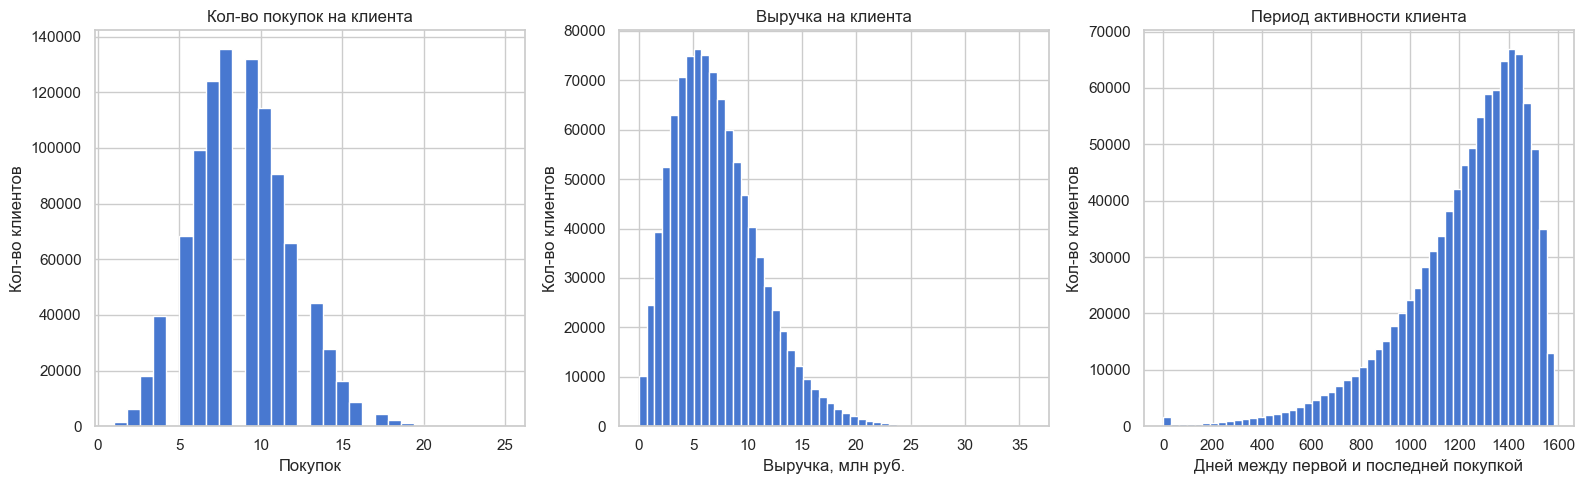

In [4]:
# графики распределения
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# распределение покупок на клиента
axes[0].hist(client_stats['покупок'], bins=30, edgecolor='white')
axes[0].set_title('Кол-во покупок на клиента')
axes[0].set_xlabel('Покупок')
axes[0].set_ylabel('Кол-во клиентов')

# распределение выручки на клиента
axes[1].hist(client_stats['выручка'] / 1e6, bins=50, edgecolor='white')
axes[1].set_title('Выручка на клиента')
axes[1].set_xlabel('Выручка, млн руб.')
axes[1].set_ylabel('Кол-во клиентов')

# распределение периода активности
axes[2].hist(client_stats['период_дней'], bins=50, edgecolor='white')
axes[2].set_title('Период активности клиента')
axes[2].set_xlabel('Дней между первой и последней покупкой')
axes[2].set_ylabel('Кол-во клиентов')

plt.tight_layout()
plt.show()

**Комментарий:**

Клиентская база зрелая — 93.5% клиентов сделали 5+ покупок, медиана 9 покупок на клиента.
Большинство активны на протяжении всего периода данных (1200-1500 дней).
Выручка распределена с длинным правым хвостом — есть небольшая группа VIP-клиентов.

## 4. LTV-анализ

Распределение клиентов по суммарной выручке за всё время. Кто входит в топ по LTV и какую долю выручки они формируют.

In [5]:
# LTV = суммарная выручка клиента за всё время
ltv = client_stats[['client_id', 'выручка']].rename(columns={'выручка': 'ltv'})

# децили LTV
ltv['дециль'] = pd.qcut(ltv['ltv'], q=10, labels=[f'D{i}' for i in range(1, 11)])
decile_stats = ltv.groupby('дециль', observed=True).agg(
    клиентов=('client_id', 'count'),
    ltv_sum=('ltv', 'sum'),
    ltv_mean=('ltv', 'mean')
).reset_index()

total_ltv = ltv['ltv'].sum()
decile_stats['доля_выручки_%'] = (decile_stats['ltv_sum'] / total_ltv * 100).round(1)
decile_stats['ltv_mean'] = decile_stats['ltv_mean'].round(0).astype(int)
print("LTV по децилям:")
display(decile_stats[['дециль', 'клиентов', 'ltv_mean', 'доля_выручки_%']])

# топ-10% клиентов
top10_revenue = decile_stats[decile_stats['дециль'] == 'D10']['ltv_sum'].values[0]
print(f"\nТоп-10% клиентов формируют {top10_revenue/total_ltv*100:.1f}% выручки")
print(f"Топ-10% порог LTV: {ltv['ltv'].quantile(0.9):,.0f} руб.")

LTV по децилям:


,дециль,клиентов,ltv_mean,доля_выручки_%
0,D1,99984,1641692,2.3
1,D2,99984,3144437,4.4
2,D3,99983,4208637,5.9
3,D4,99984,5171517,7.2
4,D5,99983,6119097,8.5
5,D6,99984,7110895,9.9
6,D7,99983,8215194,11.4
7,D8,99984,9542045,13.3
8,D9,99983,11346774,15.8
9,D10,99984,15318348,21.3



Топ-10% клиентов формируют 21.3% выручки
Топ-10% порог LTV: 12,578,964 руб.


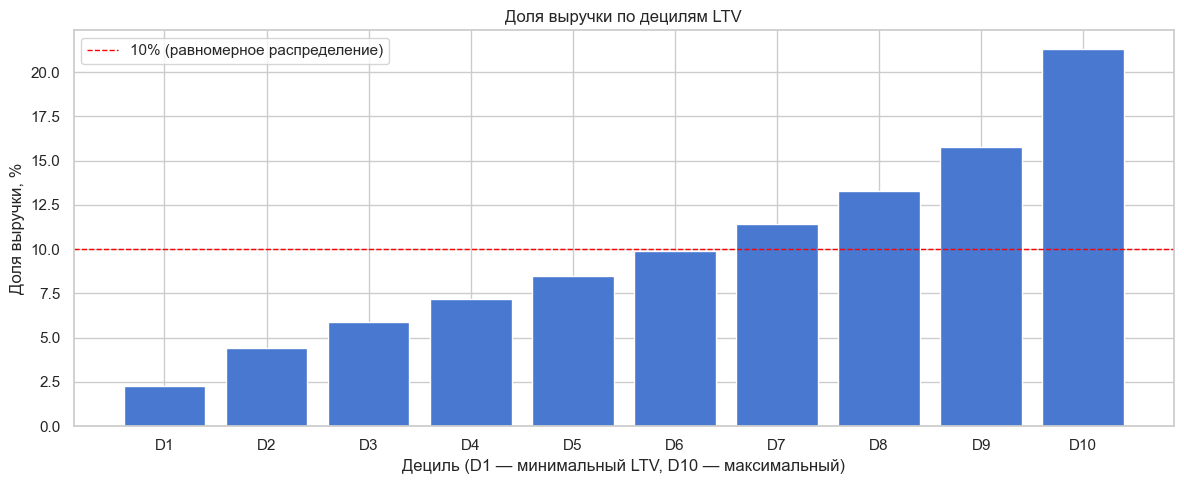

In [6]:
fig, ax = plt.subplots()
ax.bar(decile_stats['дециль'], decile_stats['доля_выручки_%'], edgecolor='white')
ax.set_title('Доля выручки по децилям LTV')
ax.set_xlabel('Дециль (D1 — минимальный LTV, D10 — максимальный)')
ax.set_ylabel('Доля выручки, %')
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='10% (равномерное распределение)')
ax.legend()
plt.tight_layout()
plt.show()

**Комментарий:**

LTV распределён относительно равномерно — особенность синтетических данных.
Топ-10% клиентов (LTV > 12.6 млн руб.) формируют 21.3% выручки.
Порог входа в топ-дециль — 12.6 млн руб. суммарных покупок за всё время.

## 5. Когортный анализ

Группируем клиентов по месяцу первой покупки (когорта).
Смотрим retention — какая доля возвращается в следующие месяцы.

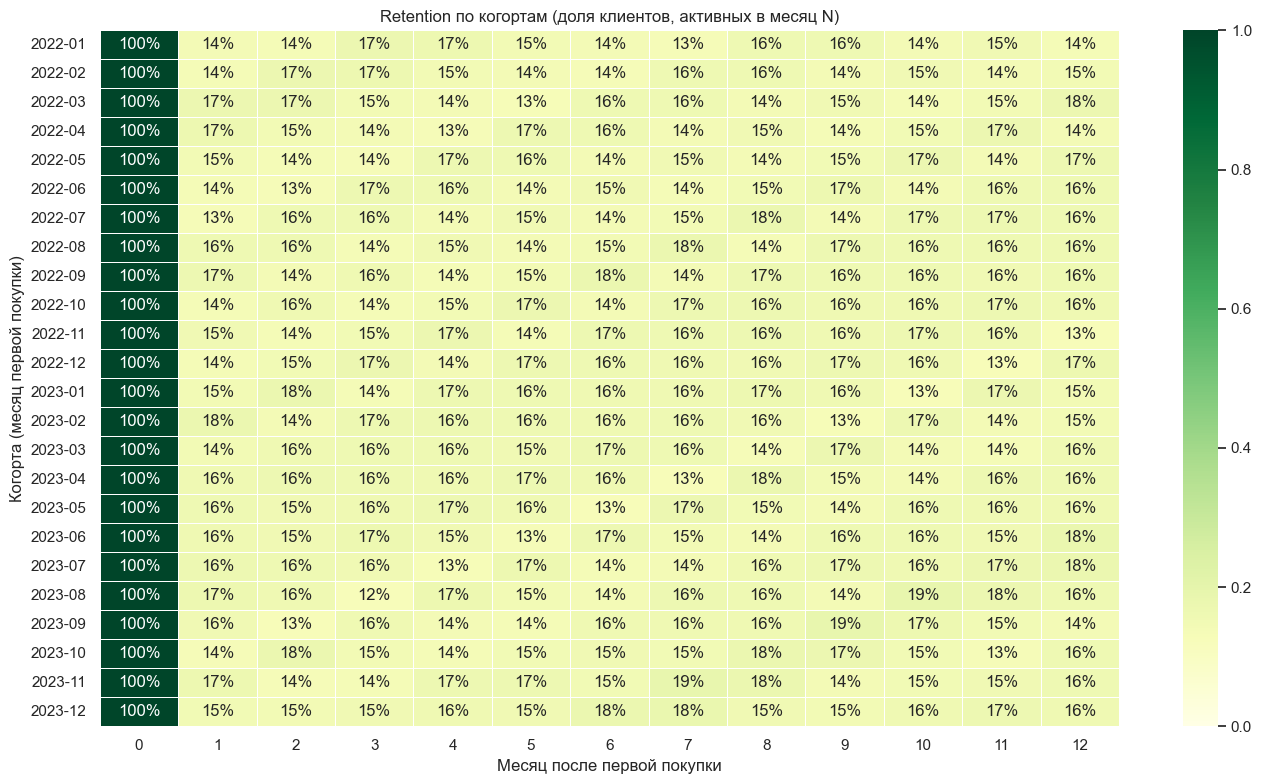

In [7]:
# определяем когорту — месяц первой покупки
client_stats['когорта'] = client_stats['первая_покупка'].dt.to_period('M')

# для каждой транзакции — месяц покупки и когорта клиента
df2 = df.merge(client_stats[['client_id', 'когорта']], on='client_id')
df2['месяц_покупки'] = df2['purchase_date'].dt.to_period('M')

# считаем retention: сколько клиентов когорты активны в каждый месяц
cohort_data = df2.groupby(['когорта', 'месяц_покупки'])['client_id'].nunique().reset_index()
cohort_data.columns = ['когорта', 'месяц_покупки', 'клиентов']

# размер когорты (месяц 0)
cohort_size = cohort_data[cohort_data['когорта'] == cohort_data['месяц_покупки']][['когорта', 'клиентов']]
cohort_size.columns = ['когорта', 'размер_когорты']

cohort_data = cohort_data.merge(cohort_size, on='когорта')
cohort_data['период'] = (cohort_data['месяц_покупки'] - cohort_data['когорта']).apply(lambda x: x.n)
cohort_data['retention'] = cohort_data['клиентов'] / cohort_data['размер_когорты']

# pivot для heatmap — только первые 12 месяцев, когорты 2022-2023
pivot = cohort_data[
    (cohort_data['период'] <= 12) & 
    (cohort_data['когорта'].astype(str) <= '2023-12')
].pivot_table(index='когорта', columns='период', values='retention')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Retention по когортам (доля клиентов, активных в месяц N)')
ax.set_xlabel('Месяц после первой покупки')
ax.set_ylabel('Когорта (месяц первой покупки)')
plt.tight_layout()
plt.show()

**Комментарий:**

Retention стабильно держится на уровне 13-19% в каждом месяце после первой покупки.
Характерно отсутствие резкого «провала» в месяц 1 — в реальных данных retention
обычно падает с 100% до 20-40% сразу после первой покупки, затем стабилизируется.
Равномерный паттерн подтверждает синтетическую природу данных.
Среднемесячный retention ~15-16% стабилен по всем когортам 2022-2023 годов.

## 6. RFM-сегментация

R (Recency) — давность последней покупки  
F (Frequency) — количество покупок  
M (Monetary) — суммарная выручка  

Каждому клиенту присваиваем сегмент от VIP до спящих.

In [8]:
# дата среза — последняя дата в данных
snapshot_date = df['purchase_date'].max()

# RFM метрики
rfm = df.groupby('client_id').agg(
    recency=('purchase_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('purchase_date', 'count'),
    monetary=('total_price', 'sum')
).reset_index()

# скоры 1-4 по каждой метрике
rfm['R'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_sum'] = rfm['R'] + rfm['F'] + rfm['M']

# сегменты
def rfm_segment(row):
    if row['RFM_sum'] >= 10:
        return 'VIP'
    elif row['RFM_sum'] >= 8:
        return 'Лояльные'
    elif row['RFM_sum'] >= 6:
        return 'Перспективные'
    elif row['R'] <= 2:
        return 'Спящие'
    else:
        return 'Группа риска'

rfm['сегмент'] = rfm.apply(rfm_segment, axis=1)

seg_summary = rfm.groupby('сегмент').agg(
    клиентов=('client_id', 'count'),
    avg_ltv=('monetary', 'mean'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean')
).round(0).astype(int)
seg_summary['доля_%'] = (seg_summary['клиентов'] / len(rfm) * 100).round(1)
display(seg_summary.sort_values('avg_ltv', ascending=False))

,клиентов,avg_ltv,avg_recency,avg_frequency,доля_%
сегмент,,,,,
VIP,245962,11266723,62,12,24.6
Лояльные,260685,8104275,132,10,26.1
Перспективные,254175,5690529,179,8,25.4
Спящие,214274,3681362,377,6,21.4
Группа риска,24740,2490935,83,5,2.5


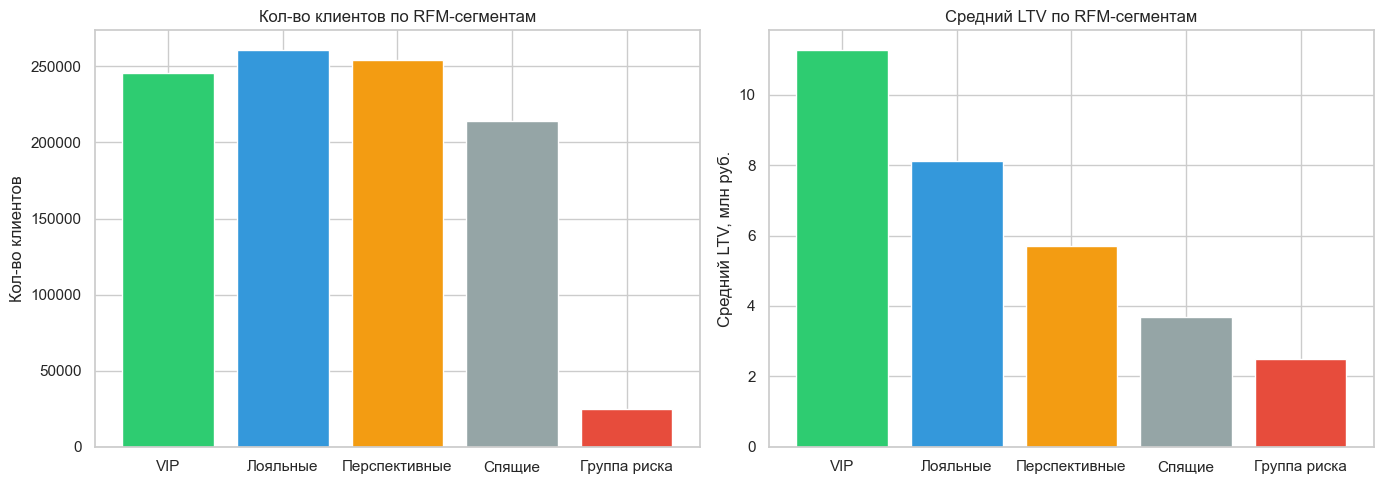

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# доля клиентов по сегментам
seg_order = ['VIP', 'Лояльные', 'Перспективные', 'Спящие', 'Группа риска']
colors = ['#2ecc71', '#3498db', '#f39c12', '#95a5a6', '#e74c3c']

axes[0].bar(seg_order, 
            seg_summary.loc[seg_order, 'клиентов'],
            color=colors, edgecolor='white')
axes[0].set_title('Кол-во клиентов по RFM-сегментам')
axes[0].set_ylabel('Кол-во клиентов')

# средний LTV по сегментам
axes[1].bar(seg_order,
            seg_summary.loc[seg_order, 'avg_ltv'] / 1e6,
            color=colors, edgecolor='white')
axes[1].set_title('Средний LTV по RFM-сегментам')
axes[1].set_ylabel('Средний LTV, млн руб.')

plt.tight_layout()
plt.show()

**RFM-сегментация клиентской базы:**
- **VIP** (24.6%, 246K клиентов) — покупали недавно (avg 62 дня назад), часто (12 покупок), высокий LTV 11.3 млн руб.
- **Лояльные** (26.1%, 261K) — активные клиенты со средним LTV 8.1 млн руб.
- **Перспективные** (25.4%, 254K) — меньше покупок, потенциал для роста
- **Спящие** (21.4%, 214K) — последняя покупка 377 дней назад, требуют реактивации
- **Группа риска** (2.5%, 25K) — мало покупок и давно, приоритет на удержание

## 7. Связь с ассортиментом

Проверяем вывод из Исследования 1: клиенты сегмента CZ — 
насколько они уникальны и что потеряем при выводе этих товаров?

In [10]:
# загружаем результаты ABC-XYZ из первого исследования
# пересчитываем прямо здесь для 2023 года
df_2023 = df[df['purchase_date'].dt.year == 2023].copy()

# ABC по выручке 2023
product_rev = df_2023.groupby('product_id')['total_price'].sum().reset_index()
product_rev = product_rev.sort_values('total_price', ascending=False).reset_index(drop=True)
product_rev['cumshare'] = product_rev['total_price'].cumsum() / product_rev['total_price'].sum()
product_rev['abc'] = product_rev['cumshare'].apply(
    lambda x: 'A' if x <= 0.8 else ('B' if x <= 0.95 else 'C')
)

# XYZ — адаптивные пороги
weekly = df_2023.copy()
weekly['week'] = weekly['purchase_date'].dt.isocalendar().week.astype(int)
weekly_stats = weekly.groupby(['product_id', 'week'])['total_price'].sum().reset_index()
cv_stats = weekly_stats.groupby('product_id')['total_price'].agg(['count', 'mean', 'std']).reset_index()
cv_stats.columns = ['product_id', 'weeks', 'mean', 'std']
cv_stats['cv'] = cv_stats['std'] / cv_stats['mean']
cv_valid = cv_stats[cv_stats['weeks'] >= 4]['cv']
p33, p66 = cv_valid.quantile(0.33), cv_valid.quantile(0.66)
cv_stats['xyz'] = cv_stats.apply(
    lambda r: 'N' if r['weeks'] < 4 else ('X' if r['cv'] <= p33 else ('Y' if r['cv'] <= p66 else 'Z')), axis=1
)

# объединяем
abc_xyz = product_rev[['product_id', 'abc']].merge(cv_stats[['product_id', 'xyz']], on='product_id', how='left')
abc_xyz['xyz'] = abc_xyz['xyz'].fillna('N')
abc_xyz['segment'] = abc_xyz['abc'] + abc_xyz['xyz']

# клиенты CZ товаров
cz_products = abc_xyz[abc_xyz['segment'] == 'CZ']['product_id']
cz_clients = df_2023[df_2023['product_id'].isin(cz_products)]['client_id'].unique()

# из них — те кто покупал ТОЛЬКО CZ товары
all_clients_2023 = df_2023.groupby('client_id')['product_id'].apply(set).reset_index()
all_clients_2023.columns = ['client_id', 'товары']
cz_set = set(cz_products)

all_clients_2023['только_cz'] = all_clients_2023['товары'].apply(
    lambda x: x.issubset(cz_set)
)

only_cz = all_clients_2023[all_clients_2023['только_cz']]
print(f"Клиентов покупавших CZ товары: {len(cz_clients):,}")
print(f"Из них покупавших ТОЛЬКО CZ товары: {len(only_cz):,} ({len(only_cz)/len(cz_clients)*100:.1f}%)")

# LTV этих клиентов
only_cz_ltv = rfm[rfm['client_id'].isin(only_cz['client_id'])]['monetary'].sum()
print(f"Суммарный LTV клиентов только CZ: {only_cz_ltv:,.0f} руб.")
print(f"Доля от общей выручки: {only_cz_ltv/rfm['monetary'].sum()*100:.2f}%")

Клиентов покупавших CZ товары: 149,309
Из них покупавших ТОЛЬКО CZ товары: 22,953 (15.4%)
Суммарный LTV клиентов только CZ: 132,191,221,102 руб.
Доля от общей выручки: 1.84%


**Связь клиентов с CZ-товарами:**
- 149 309 клиентов покупали CZ-товары в 2023 году
- Из них только 22 953 клиента (15.4%) покупали **исключительно** CZ-товары
- Их суммарный LTV — 132 млрд руб. (1.84% от общей выручки)

**Вывод:** при выводе сегмента CZ из ассортимента риск потери клиентов минимален.
84.6% покупателей CZ-товаров также покупают товары других сегментов — они останутся.
Потенциальные потери: 22 953 клиента с LTV 132 млрд руб. (1.84% выручки),
что сопоставимо с долей самих CZ-товаров в выручке (1.8%).
Это подтверждает рекомендацию из Исследования 1 о выводе CZ.

## 8. Выводы и рекомендации

Конкретные рекомендации по работе с клиентскими сегментами.

### Рекомендация 1: Программа удержания Спящих клиентов
- **Аудитория:** 214 274 клиента, последняя покупка 377 дней назад
- **Средний LTV:** 3.7 млн руб. — есть что терять
- **Действие:** персональные офферы с умеренной скидкой (10-15%) на товары AX/AY
- **Ожидаемый эффект:** возврат даже 10% спящих = +21 000 активных клиентов

### Рекомендация 2: Развитие VIP-сегмента
- **Аудитория:** 245 962 клиента, средний LTV 11.3 млн руб.
- **Действие:** приоритетный сервис, ранний доступ к новинкам, минимум скидок
- **Логика:** VIP покупают часто и недавно — скидки им не нужны, нужен сервис

### Рекомендация 3: Конвертация Перспективных в Лояльных
- **Аудитория:** 254 175 клиентов, avg 8 покупок, LTV 5.7 млн руб.
- **Действие:** программа лояльности с накопительными бонусами
- **Ожидаемый эффект:** рост частоты покупок на 20% = +1.1 млн руб. к среднему LTV

### Рекомендация 4: Вывод CZ безопасен для клиентской базы
- Только 1.84% выручки приходится на клиентов, покупающих исключительно CZ
- 84.6% покупателей CZ также покупают другие товары — не уйдут
- Вывод CZ можно проводить без программы компенсации для клиентов

### Рекомендация 5: Реактивация Группы риска
- **Аудитория:** 24 740 клиентов, мало покупок, но относительно недавние (83 дня)
- **Действие:** win-back кампания с персональным предложением в течение 30 дней
- **Логика:** клиент ещё помнит бренд — окно для возврата открыто

### Какие метрики стоит и не стоит растить
LTV = AOV (средний чек) × Frequency (частота покупок) × Lifetime (срок жизни клиента)
Анализ показывает:
- **Frequency** — медиана 9 покупок на клиента, 93.5% делают 5+. Растить дальше малоосмысленно — клиенты уже активны.
- **Lifetime** — большинство активны 1200–1500 дней (весь период данных). Это уже потолок, дальше расти некуда без роста срока наблюдения.
- **AOV (средний чек)** — главный рычаг. Сейчас средний чек снижается из-за скидок (см. Исследование 1: средняя выручка позиции падает в 8 раз с ростом скидки). Это значит: сократив скидки, мы автоматически растим AOV → растим LTV.

**Главный вывод:** для роста LTV нужно работать не над количеством покупок (его уже достаточно), а над выручкой каждой покупки. Это смыкается с рекомендацией из Исследования 1 о сокращении скидок на AX — это одновременно решение и для ассортимента, и для LTV.

**Что НЕ стоит растить:**
- Retention уже стабильный 13–19% — попытки агрессивно его двигать дороже выигрыша
- Frequency — у активной части базы упёрлась в потолок

**Что стоит растить:**
- AOV через сокращение скидок на AX (потенциал +27% к среднему чеку при возврате 50% упущенной выручки)
- Конверсию Спящих обратно в Активных — это даёт +21K активных клиентов (+рост базы покупающих, что важнее, чем рост частоты у уже активных)

## 9. Резюме

**Клиентская база:**
- 999 836 клиентов за полный период 2022-2026, медиана 9 покупок на клиента
- 93.5% клиентов сделали 5+ покупок — база зрелая и активная
- Retention стабилен на уровне 13-19% ежемесячно по всем когортам 2022-2023
- RFM-сегментация: VIP (25%) и Лояльные (26%) формируют основу базы; 
  21% клиентов — Спящие, требуют реактивации

**Главный рычаг роста LTV — средний чек, не частота:**
- Frequency и Lifetime у активной части базы уже на потолке — растить нет смысла
- AOV сейчас задавлен скидками (средняя выручка позиции падает в 8 раз с ростом скидки)
- Сокращение скидок на AX (см. Исследование 1) одновременно решает задачу 
  ассортимента и растит LTV — это связующий вывод двух исследований

**Что стоит и не стоит растить:**
- Растить: AOV (сокращение скидок), долю активных клиентов (реактивация Спящих)
- Не растить агрессивно: Retention (уже стабильный), Frequency у активных (потолок)

**Связь с ассортиментом:**
- Вывод сегмента CZ безопасен для базы: только 1.84% выручки приходится 
  на клиентов, покупающих исключительно CZ-товары

**Приоритет действий:**
1. Сокращение скидок на AX → рост AOV → рост LTV (главный эффект)
2. Удержание Спящих (214K клиентов, +21K активных при возврате 10%)
3. Развитие VIP без скидок (приоритетный сервис вместо демпинга)
4. Конвертация Перспективных в Лояльных через программу лояльности
5. Win-back Группы риска (24K клиентов с открытым окном возврата)